# Mitigation Analysis — priority intersections

Crash-**reason** and **KABCO injury-severity** breakdowns for the intersections flagged for mitigation, grouped by **priority**. Source: crashes at or near an intersection — `INTERSECTION_RELATED_I` is `Y` **or blank** (everything except explicit `N`) — in the 27th Ward, each assigned to its nearest ward intersection. Multi-node *systems* (diagonal Ogden, split Randolph) are aggregated.

**Curated taxonomy** (applied to every chart):
- **Crash type:** `PEDESTRIAN` is always shown as its own category (distinct from `PEDALCYCLIST` = bikes).
- **Crash reason:** four signal/sign-running causes are grouped as **Disregarding Traffic Signals**; **WEATHER + VISION OBSCURED + ROAD ENGINEERING/SURFACE/MARKING DEFECTS** are grouped as **Visibility**; `IMPROPER LANE USAGE` is surfaced. Anything outside the displayed categories falls in **Other** (grey).

| priority | intersections |
|---|---|
| **High** | N Kedzie & W Chicago · Western & Madison · S Leavitt & W Van Buren · S Paulina & W Roosevelt |
| **Medium** | W Congress & Ogden (+ Wolcott) · S Marshfield & W Taylor · N Morgan & Randolph (N+S) |

**KABCO:** K = fatal, A = incapacitating, B = non-incapacitating, C = possible, O = no injury.

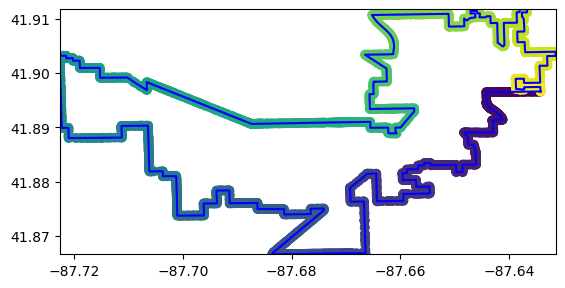

43,730 crashes (Y or blank) across 1002 ward intersections


In [1]:
import pandas as pd, numpy as np, geopandas as gpd
import matplotlib.pyplot as plt, matplotlib.cm as cm
from shapely import wkt
from coordinate_to_ward import *
from street_intersections import *

our_ward = ward_shape(27)
all_crashes = pd.read_csv('Traffic_Crashes_-_Crashes_20260622.csv', low_memory=False).dropna(subset=['LOCATION'])
all_crashes['LOCATION'] = all_crashes['LOCATION'].apply(wkt.loads)
all_crashes = gpd.GeoDataFrame(all_crashes, geometry='LOCATION', crs='EPSG:4326')
# Broader set: Y or blank (exclude only explicit 'N').
near_intersection = all_crashes[all_crashes.LOCATION.within(our_ward)
                                & (all_crashes['INTERSECTION_RELATED_I'] != 'N')].copy()

ints = intersections.reset_index().dropna(subset=['lon', 'lat'])
ward_intersections = gpd.GeoDataFrame(ints, geometry=gpd.points_from_xy(ints.lon, ints.lat), crs='EPSG:4326')
ward_intersections = ward_intersections[ward_intersections.within(our_ward)].reset_index(drop=True)
assigned = gpd.sjoin_nearest(near_intersection.to_crs(3435), ward_intersections.to_crs(3435)[['geometry']])
assigned = assigned[~assigned.index.duplicated(keep='first')]   # one nearest intersection per crash

KABCO = [('K', 'INJURIES_FATAL'), ('A', 'INJURIES_INCAPACITATING'), ('B', 'INJURIES_NON_INCAPACITATING'),
         ('C', 'INJURIES_REPORTED_NOT_EVIDENT'), ('O', 'INJURIES_NO_INDICATION')]
KABCO_COST = {'K': 2_050_000, 'A': 174_000, 'B': 45_000, 'C': 28_000, 'O': 7_700}
print(f'{len(near_intersection):,} crashes (Y or blank) across {len(ward_intersections)} ward intersections')

In [2]:
# --- Display taxonomy: collapse raw crash type / reason into the curated categories ---
TYPE_CATS = ['ANGLE', 'TURNING', 'REAR END', 'SIDESWIPE SAME DIRECTION', 'PARKED MOTOR VEHICLE',
             'FIXED OBJECT', 'PEDESTRIAN', 'PEDALCYCLIST']
def type_cat(x):
    return x if x in TYPE_CATS else 'Other'

CAUSE_MAP = {  # raw PRIM_CONTRIBUTORY_CAUSE -> grouped display category
    'DISREGARDING TRAFFIC SIGNALS': 'Disregarding Traffic Signals',
    'DISREGARDING STOP SIGN': 'Disregarding Traffic Signals',
    'DISREGARDING OTHER TRAFFIC SIGNS': 'Disregarding Traffic Signals',
    'DISREGARDING YIELD SIGN': 'Disregarding Traffic Signals',
    'WEATHER': 'Visibility',
    'VISION OBSCURED (SIGNS, TREE LIMBS, BUILDINGS, ETC.)': 'Visibility',
    'ROAD ENGINEERING/SURFACE/MARKING DEFECTS': 'Visibility',
}
CAUSE_CATS = ['FAILING TO YIELD RIGHT-OF-WAY', 'FOLLOWING TOO CLOSELY', 'IMPROPER OVERTAKING/PASSING',
              'IMPROPER BACKING', 'IMPROPER TURNING/NO SIGNAL', 'IMPROPER LANE USAGE',
              'FAILING TO REDUCE SPEED TO AVOID CRASH', 'Disregarding Traffic Signals', 'Visibility',
              'NOT APPLICABLE', 'UNABLE TO DETERMINE']
def cause_cat(x):
    c = CAUSE_MAP.get(x, x)
    return c if c in CAUSE_CATS else 'Other'

assigned['ctype'] = assigned['FIRST_CRASH_TYPE'].map(type_cat)
assigned['ccause'] = assigned['PRIM_CONTRIBUTORY_CAUSE'].map(cause_cat)

# Fixed colours so a category is the same colour in every chart ('Other' = grey).
TYPE_ORDER = TYPE_CATS + ['Other']
CAUSE_ORDER = CAUSE_CATS + ['Other']
TYPE_COLORS  = {c: ('#bdbdbd' if c == 'Other' else cm.tab20(i % 20)) for i, c in enumerate(TYPE_ORDER)}
CAUSE_COLORS = {c: ('#bdbdbd' if c == 'Other' else cm.tab20(i % 20)) for i, c in enumerate(CAUSE_ORDER)}

def composition(crashes, kind):
    """% of crashes in each display category (full ordered set incl. Other)."""
    col, order = (('ctype', TYPE_ORDER) if kind == 'type' else ('ccause', CAUSE_ORDER))
    if crashes is None or len(crashes) == 0:
        return pd.Series(0.0, index=order)
    return (crashes[col].value_counts(normalize=True) * 100).reindex(order).fillna(0)

print('crash types:', TYPE_ORDER)
print('crash reasons:', CAUSE_ORDER)

crash types: ['ANGLE', 'TURNING', 'REAR END', 'SIDESWIPE SAME DIRECTION', 'PARKED MOTOR VEHICLE', 'FIXED OBJECT', 'PEDESTRIAN', 'PEDALCYCLIST', 'Other']
crash reasons: ['FAILING TO YIELD RIGHT-OF-WAY', 'FOLLOWING TOO CLOSELY', 'IMPROPER OVERTAKING/PASSING', 'IMPROPER BACKING', 'IMPROPER TURNING/NO SIGNAL', 'IMPROPER LANE USAGE', 'FAILING TO REDUCE SPEED TO AVOID CRASH', 'Disregarding Traffic Signals', 'Visibility', 'NOT APPLICABLE', 'UNABLE TO DETERMINE', 'Other']


In [3]:
# Priority groups. Each intersection is a SYSTEM = union of ward nodes matching any street-keyword pair.
PRIORITY = {
    'High': {
        'N Kedzie Ave & W Chicago Ave':    [('KEDZIE', 'CHICAGO')],
        'Western & Madison':               [('WESTERN', 'MADISON')],
        'S Leavitt St & W Van Buren St':   [('LEAVITT', 'VAN BUREN')],
        'S Paulina St & W Roosevelt Rd':   [('PAULINA', 'ROOSEVELT')],
    },
    'Medium': {
        'W Congress Pkwy & W Ogden Ave (+ Wolcott)': [('CONGRESS', 'OGDEN'), ('WOLCOTT', 'CONGRESS'), ('WOLCOTT', 'OGDEN')],
        'S Marshfield Ave & W Taylor St':            [('MARSHFIELD', 'TAYLOR')],
        'N Morgan St & W Randolph St (N+S)':         [('MORGAN', 'RANDOLPH')],
    },
}
def system_nodes(pairs):
    idx = set()
    for a, b in pairs:
        m = (ward_intersections['streets'].str.contains(a, case=False, na=False)
             & ward_intersections['streets'].str.contains(b, case=False, na=False))
        idx |= set(ward_intersections.index[m])
    return sorted(idx)

systems = []
for priority, items in PRIORITY.items():
    for name, pairs in items.items():
        nodes = system_nodes(pairs)
        systems.append({'priority': priority, 'name': name, 'nodes': nodes,
                        'streets': ' | '.join(ward_intersections.loc[nodes, 'streets']),
                        'crashes': assigned[assigned['index_right'].isin(nodes)]})

def kabco_counts(c):
    return {k: int(c[col].fillna(0).sum()) for k, col in KABCO}

for s in systems:
    print(f"[{s['priority']:6}] {s['name']:44} nodes={s['nodes']}  crashes={len(s['crashes'])}")

[High  ] N Kedzie Ave & W Chicago Ave                 nodes=[727]  crashes=456
[High  ] Western & Madison                            nodes=[917]  crashes=521
[High  ] S Leavitt St & W Van Buren St                nodes=[319]  crashes=52
[High  ] S Paulina St & W Roosevelt Rd                nodes=[314]  crashes=213
[Medium] W Congress Pkwy & W Ogden Ave (+ Wolcott)    nodes=[589, 829, 936]  crashes=372
[Medium] S Marshfield Ave & W Taylor St               nodes=[563]  crashes=154
[Medium] N Morgan St & W Randolph St (N+S)            nodes=[119, 125, 652]  crashes=149


In [4]:
# Summary table, grouped by priority. "top_*" use the curated categories (excluding non-causes).
NONCAUSE = {'UNABLE TO DETERMINE', 'NOT APPLICABLE', 'Other'}
rows = []
for s in systems:
    c = s['crashes']; kc = kabco_counts(c)
    ct = c['ctype'].value_counts(); ct = ct[ct.index != 'Other']
    cc = c['ccause'].value_counts(); cc = cc[~cc.index.isin(NONCAUSE)]
    rows.append({'priority': s['priority'], 'intersection': s['name'], 'crashes': len(c),
                 **kc, 'injured (K-C)': kc['K'] + kc['A'] + kc['B'] + kc['C'],
                 'injury_cost': sum(kc[k] * KABCO_COST[k] for k in kc),
                 'top_crash_type': ct.index[0] if len(ct) else '',
                 'top_cause': cc.index[0] if len(cc) else ''})
summary = pd.DataFrame(rows)
summary_fmt = summary.copy(); summary_fmt['injury_cost'] = summary_fmt['injury_cost'].map('${:,.0f}'.format)
summary_fmt

,priority,intersection,crashes,K,A,B,C,O,injured (K-C),injury_cost,top_crash_type,top_cause
0,High,N Kedzie Ave & W Chicago Ave,456,3,10,58,45,961,116,"$19,159,700",PARKED MOTOR VEHICLE,FAILING TO YIELD RIGHT-OF-WAY
1,High,Western & Madison,521,0,13,53,19,1033,85,"$13,133,100",PARKED MOTOR VEHICLE,FAILING TO YIELD RIGHT-OF-WAY
2,High,S Leavitt St & W Van Buren St,52,0,4,24,9,98,37,"$2,782,600",ANGLE,Disregarding Traffic Signals
3,High,S Paulina St & W Roosevelt Rd,213,0,7,19,22,502,48,"$6,554,400",REAR END,FOLLOWING TOO CLOSELY
4,Medium,W Congress Pkwy & W Ogden Ave (+ Wolcott),372,0,12,64,42,885,118,"$12,958,500",ANGLE,FAILING TO YIELD RIGHT-OF-WAY
5,Medium,S Marshfield Ave & W Taylor St,154,0,2,31,13,365,46,"$4,917,500",TURNING,FAILING TO YIELD RIGHT-OF-WAY
6,Medium,N Morgan St & W Randolph St (N+S),149,1,2,14,3,299,20,"$5,414,300",PARKED MOTOR VEHICLE,IMPROPER BACKING


In [5]:
# Per-intersection detail: KABCO injuries + curated crash type & reason composition.
def detail(s):
    c = s['crashes']; kc = kabco_counts(c); cost = sum(kc[k] * KABCO_COST[k] for k in kc)
    print('=' * 92)
    print(f"{s['priority'].upper()}  |  {s['name']}   ({len(c)} crashes)")
    print(f"nodes {s['nodes']}: {s['streets']}")
    print('\nKABCO injury breakdown (persons):  ' + '   '.join(f'{k}={kc[k]}' for k, _ in KABCO))
    print(f'comprehensive injury cost: ${cost:,.0f}')
    for kind, label in [('type', 'Crash type'), ('cause', 'Crash reason')]:
        comp = composition(c, kind).sort_values(ascending=False)
        print(f'\n{label} (% of crashes):')
        print(comp[comp > 0].round(1).to_string())

def detail_group(priority):
    for s in systems:
        if s['priority'] == priority:
            detail(s); print()

## High-priority intersections

In [6]:
detail_group('High')

HIGH  |  N Kedzie Ave & W Chicago Ave   (456 crashes)
nodes [727]: N KEDZIE AVE & W CHICAGO AVE

KABCO injury breakdown (persons):  K=3   A=10   B=58   C=45   O=961
comprehensive injury cost: $19,159,700

Crash type (% of crashes):
ctype
PARKED MOTOR VEHICLE        20.6
TURNING                     16.9
ANGLE                       16.4
REAR END                    15.6
SIDESWIPE SAME DIRECTION    11.0
Other                        7.0
PEDESTRIAN                   6.1
FIXED OBJECT                 4.6
PEDALCYCLIST                 1.8

Crash reason (% of crashes):
ccause
UNABLE TO DETERMINE                       43.2
FAILING TO YIELD RIGHT-OF-WAY              9.9
Other                                      8.3
FOLLOWING TOO CLOSELY                      7.0
IMPROPER BACKING                           5.7
Disregarding Traffic Signals               4.6
IMPROPER OVERTAKING/PASSING                4.4
FAILING TO REDUCE SPEED TO AVOID CRASH     4.4
IMPROPER TURNING/NO SIGNAL                 4.2
NOT A

## Medium-priority intersections

In [7]:
detail_group('Medium')

MEDIUM  |  W Congress Pkwy & W Ogden Ave (+ Wolcott)   (372 crashes)
nodes [589, 829, 936]: W CONGRESS PKWY & W OGDEN AVE | S WOLCOTT AVE & W CONGRESS PKWY | S WOLCOTT AVE & W OGDEN AVE

KABCO injury breakdown (persons):  K=0   A=12   B=64   C=42   O=885
comprehensive injury cost: $12,958,500

Crash type (% of crashes):
ctype
ANGLE                       72.6
TURNING                      9.1
REAR END                     6.5
SIDESWIPE SAME DIRECTION     4.6
Other                        4.0
PEDALCYCLIST                 1.3
PEDESTRIAN                   1.1
PARKED MOTOR VEHICLE         0.5
FIXED OBJECT                 0.3

Crash reason (% of crashes):
ccause
FAILING TO YIELD RIGHT-OF-WAY             50.0
UNABLE TO DETERMINE                       28.8
Disregarding Traffic Signals               7.5
FOLLOWING TOO CLOSELY                      3.8
Visibility                                 2.7
FAILING TO REDUCE SPEED TO AVOID CRASH     2.2
NOT APPLICABLE                             1.6
Other    

## Visual summary (per intersection)

Injury-severity profile (injured persons K/A/B/C; the "O = no injury" majority is excluded so severity is visible) and the curated **crash-type** composition. Bars ordered High -> Medium.

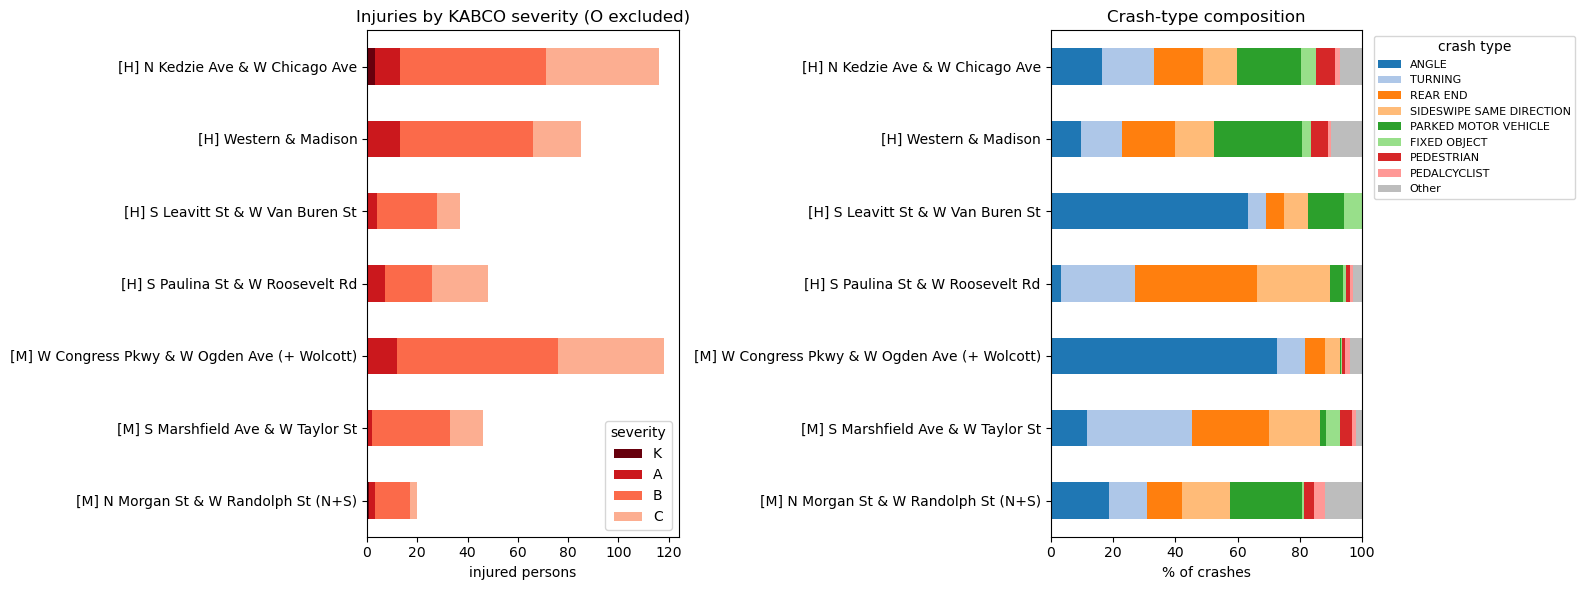

In [8]:
labels = [f"[{'H' if s['priority']=='High' else 'M'}] {s['name']}" for s in systems]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
# 1) injured persons by KABCO severity (exclude O)
kdf = pd.DataFrame([{k: kabco_counts(s['crashes'])[k] for k in ['K', 'A', 'B', 'C']} for s in systems], index=labels)
kdf.plot(kind='barh', stacked=True, ax=ax1, color=['#67000d', '#cb181d', '#fb6a4a', '#fcae91'])
ax1.invert_yaxis(); ax1.set_xlabel('injured persons'); ax1.set_title('Injuries by KABCO severity (O excluded)')
ax1.legend(title='severity', loc='lower right')
# 2) crash-type composition (curated categories, consistent colours)
comp = pd.DataFrame({s['name']: composition(s['crashes'], 'type') for s in systems}).T
comp.index = labels
comp[TYPE_ORDER].plot(kind='barh', stacked=True, ax=ax2, color=[TYPE_COLORS[c] for c in TYPE_ORDER])
ax2.invert_yaxis(); ax2.set_xlim(0, 100); ax2.set_xlabel('% of crashes'); ax2.set_title('Crash-type composition')
ax2.legend(title='crash type', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

## Crash reason by intersection

Curated **primary-cause** composition per intersection (signal/sign-running grouped as *Disregarding Traffic Signals*; weather/vision/road-defect grouped as *Visibility*).

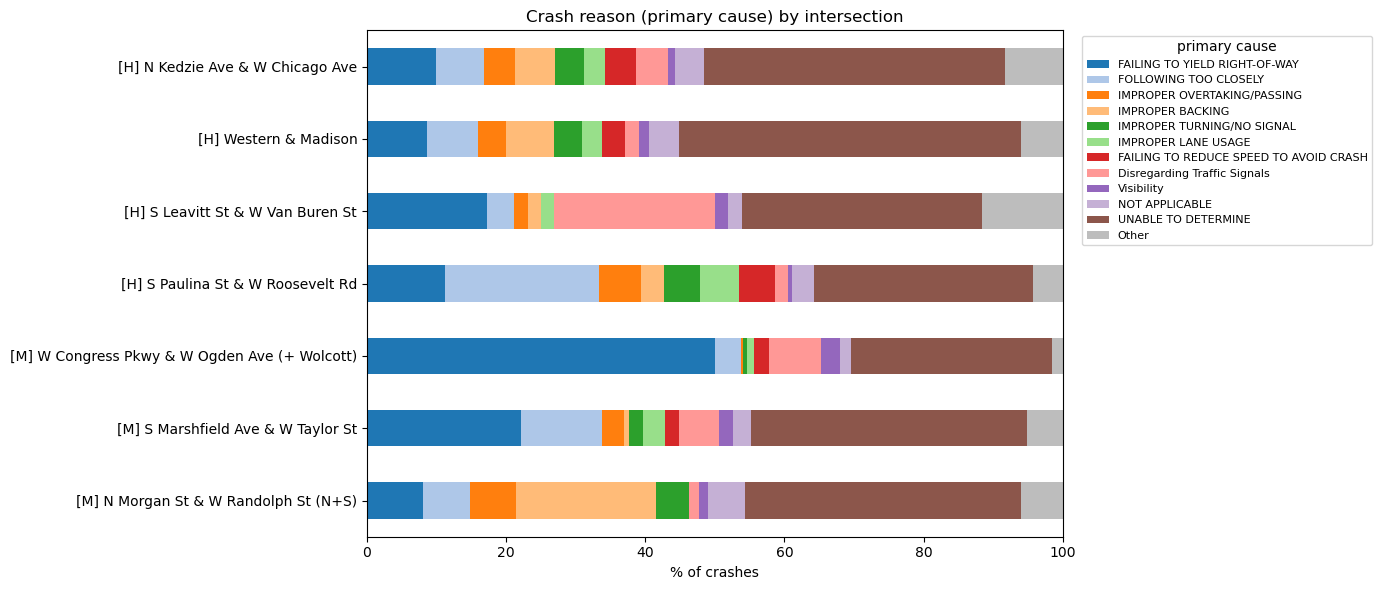

In [9]:
comp = pd.DataFrame({s['name']: composition(s['crashes'], 'cause') for s in systems}).T
comp.index = [f"[{'H' if s['priority']=='High' else 'M'}] {s['name']}" for s in systems]
ax = comp[CAUSE_ORDER].plot(kind='barh', stacked=True, figsize=(14, 6), color=[CAUSE_COLORS[c] for c in CAUSE_ORDER])
ax.invert_yaxis(); ax.set_xlim(0, 100); ax.set_xlabel('% of crashes'); ax.set_title('Crash reason (primary cause) by intersection')
ax.legend(title='primary cause', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

## Reference: safer-than-expected intersections

To benchmark the priority sites we rebuild the **context screening model** from `Crash_Analysis` (Negative-Binomial on `Y`-only intersection crashes) and flag intersections with factor **≤ 0.5** (fewer than half the crashes their volume / junction size / density / crime predict). The crash *profiles* below use this notebook's Y-or-blank set, for comparability.

In [10]:
# Rebuild the context-only screening factor (Y-only model) to flag safer-than-expected intersections.
import statsmodels.formula.api as smf, statsmodels.api as sm
intersection_related = all_crashes[all_crashes.LOCATION.within(our_ward)
                                   & (all_crashes['INTERSECTION_RELATED_I'] == 'Y')].copy()
wi3435 = ward_intersections.to_crs(3435)
cmin = int(pd.to_datetime(all_crashes['CRASH_DATE']).min().year)
ward_3435 = gpd.GeoSeries([our_ward], crs='EPSG:4326').to_crs(3435).iloc[0]

aadt = gpd.read_file('idot_aadt/Annual_Average_Daily_Traffic_(AADT).geojson').to_crs(3435)
aadt = aadt[aadt.intersects(ward_3435)]
ex = aadt['ROAD_NAME'].str.contains('Expwy|Ramp| to I| EB| WB| NB| SB|CD ', case=False, na=False) | aadt['MARKED_NAM'].str.match(r'I\d', na=False)
surf = aadt[~ex].copy(); surf['road'] = surf['ROAD_NAME'].str.upper().str.strip()
ab = wi3435[['geometry']].copy(); ab['geometry'] = ab.buffer(100); ab['iid'] = ab.index
entering = gpd.sjoin(ab, surf[['road', 'AADT', 'geometry']], predicate='intersects').groupby(['iid', 'road'])['AADT'].max().groupby('iid').sum()

blocks = gpd.read_file('census/tl_2020_17_tabblock20.zip', bbox=tuple(our_ward.bounds)).to_crs('EPSG:4326')
blocks = blocks[blocks.intersects(our_ward)].copy(); blocks['POP20'] = blocks['POP20'].astype(int)
blocks['density'] = np.where(blocks['ALAND20'] > 0, blocks['POP20'] / (blocks['ALAND20'] / 1e6), 0)
b50 = wi3435[['geometry']].copy(); b50['geometry'] = b50.buffer(50); b50['iid'] = b50.index
dens = gpd.sjoin(b50, blocks[['density', 'geometry']].to_crs(3435), predicate='intersects').groupby('iid')['density'].mean()
crime = pd.read_csv('crime/ijzp-q8t2.csv', usecols=['primary_type', 'year', 'latitude', 'longitude'], low_memory=False)
crime = crime[crime['primary_type'].isin(['HOMICIDE', 'ASSAULT', 'BATTERY']) & (crime['year'] >= cmin)].dropna(subset=['latitude', 'longitude'])
cg = gpd.GeoDataFrame(crime, geometry=gpd.points_from_xy(crime.longitude, crime.latitude), crs='EPSG:4326')
cg = cg[cg.within(our_ward)].to_crs(3435)
b500 = wi3435[['geometry']].copy(); b500['geometry'] = b500.buffer(500); b500['iid'] = b500.index
crime_by_int = gpd.sjoin(b500, cg[['geometry']], predicate='intersects').groupby('iid').size()
blk = blocks[['POP20', 'geometry']].to_crs(3435).copy(); blk['blk_area'] = blk.geometry.area
ovl = gpd.overlay(b500[['iid', 'geometry']], blk, how='intersection'); ovl['pop'] = ovl['POP20'] * (ovl.geometry.area / ovl['blk_area'])
pop_by_int = ovl.groupby('iid')['pop'].sum(); POP_FLOOR = float(pop_by_int[pop_by_int > 0].quantile(.05))

nnY = gpd.sjoin_nearest(intersection_related.to_crs(3435), wi3435[['geometry']]); nnY = nnY[~nnY.index.duplicated(keep='first')]
f = pd.DataFrame({'n_crashes': nnY.groupby('index_right').size()})
f['num_streets'] = ward_intersections['num_streets'].astype(float)
f['entering_aadt'] = f.index.map(entering)
f['crime'] = f.index.map(crime_by_int).fillna(0)
f['pop_buf'] = f.index.map(pop_by_int); f['pop_buf'] = f['pop_buf'].fillna(POP_FLOOR).clip(lower=POP_FLOOR)
f['log_crime_rate'] = np.log1p(1000 * f['crime'] / f['pop_buf'])
f['log_density'] = np.log1p(f.index.map(dens).fillna(0))
f['streets'] = ward_intersections['streets']
rampf = f['streets'].str.contains(r'KENNEDY|EISENHOWER|EXPWY|EXPRESSWAY|RAMP| ER\b| XR\b', case=False, na=False)
f = f[f['entering_aadt'].notna() & ~rampf].copy(); f['log_aadt'] = np.log(f['entering_aadt'])
for c in ['log_aadt', 'num_streets', 'log_density', 'log_crime_rate']:
    f['z_' + c] = (f[c] - f[c].mean()) / f[c].std()
nbmod = smf.negativebinomial('n_crashes ~ z_log_aadt + z_num_streets + z_log_density + z_log_crime_rate', data=f).fit(disp=0, maxiter=500)
mu = nbmod.predict(); alpha = nbmod.params['alpha']; wts = 1 / (1 + alpha * mu)
f['factor'] = (wts * mu + (1 - wts) * f['n_crashes']) / mu
safe_nodes = f.index[f['factor'] <= 0.5]
print(f'context model on {len(f)} intersections | {len(safe_nodes)} safer-than-expected (factor <= 0.5)')

C:\Users\kennyge2\AppData\Local\Temp\ipykernel_20920\1746912384.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cmin = int(pd.to_datetime(all_crashes['CRASH_DATE']).min().year)


context model on 590 intersections | 222 safer-than-expected (factor <= 0.5)


## Composition: each priority site vs. average vs. safer-than-expected

100%-stacked (compound) bars, curated categories with consistent colours. Top two rows are references — **all intersections (average)** and the **safer-than-expected** sites (factor ≤ 0.5) — then, below the divider, each of the **7 priority intersections**, so every profile lines up on one axis. Read the shift in segment widths.

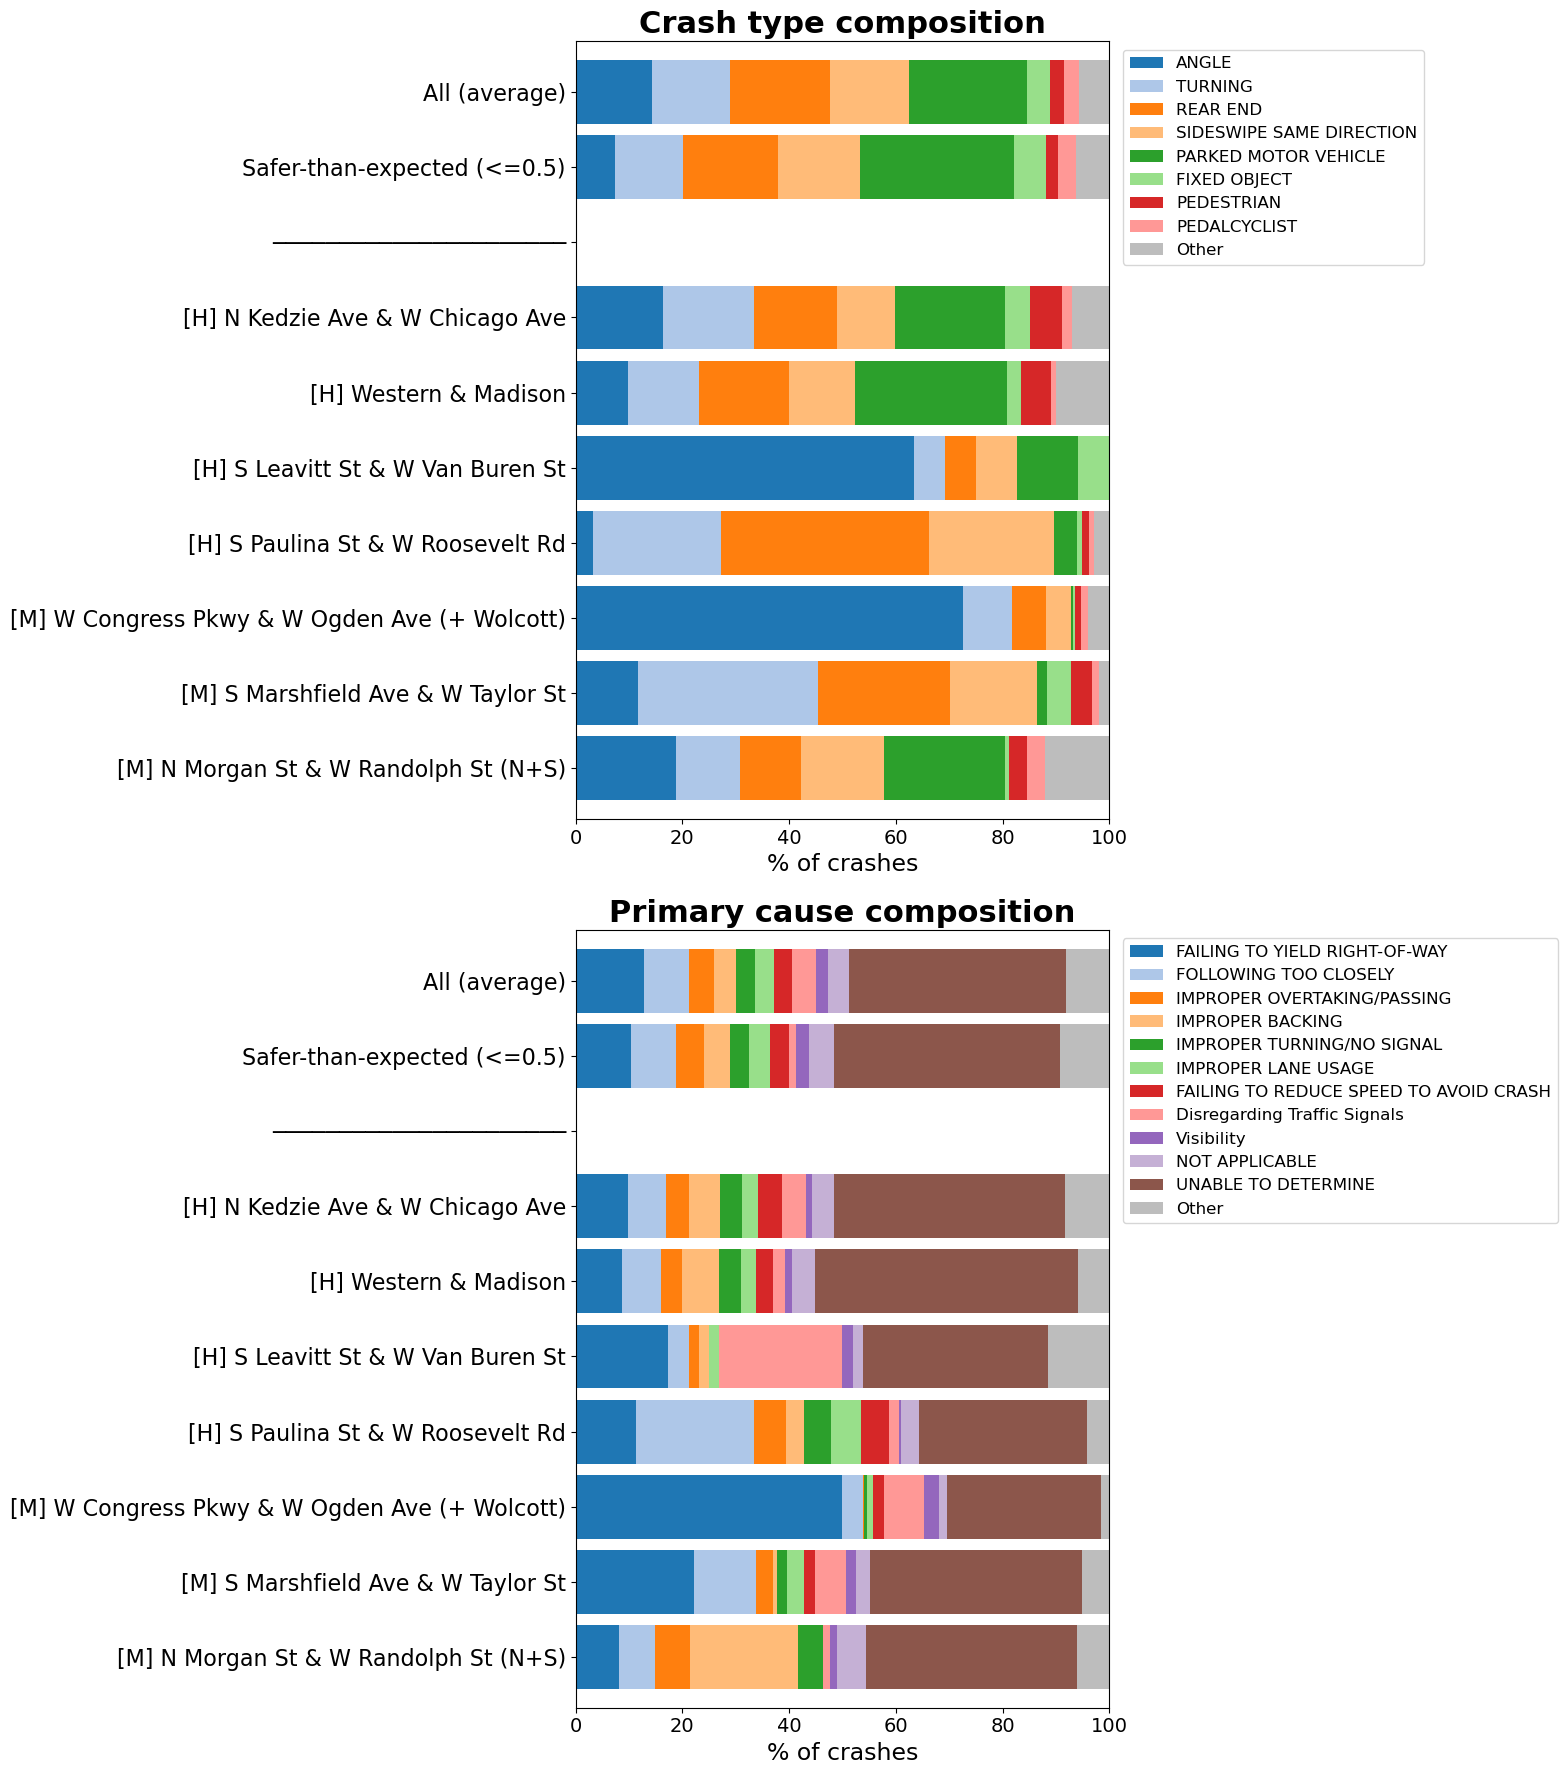

In [11]:
avg_crashes  = assigned
safe_crashes = assigned[assigned['index_right'].isin(safe_nodes)]
DIV = '\u2500' * 22
rows = [('All (average)', avg_crashes), ('Safer-than-expected (<=0.5)', safe_crashes), (DIV, None)]
rows += [(f"[{'H' if s['priority']=='High' else 'M'}] {s['name']}", s['crashes']) for s in systems]

plt.rcParams.update({'font.size': 15})
fig, axes = plt.subplots(2, 1, figsize=(16, 18))
for ax, (kind, order, colors, title) in zip(
        axes, [('type', TYPE_ORDER, TYPE_COLORS, 'Crash type'),
               ('cause', CAUSE_ORDER, CAUSE_COLORS, 'Primary cause')]):
    comp = pd.DataFrame({label: composition(cr, kind) for label, cr in rows}).T[order]
    comp.iloc[::-1].plot(kind='barh', stacked=True, ax=ax, color=[colors[c] for c in order], width=0.85)
    ax.set_xlim(0, 100)
    ax.set_title(f'{title} composition', fontsize=22, weight='bold')
    ax.set_xlabel('% of crashes', fontsize=17)
    ax.tick_params(axis='y', labelsize=16); ax.tick_params(axis='x', labelsize=14)
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=12)
plt.tight_layout(); plt.show()
plt.rcParams.update({'font.size': 10})